# Lab 6 — Punto 1: KMeans, Método del Codo y Silhouette Score

**Objetivo:** generar un dataset sintético con un número aleatorio de centroides (entre 1 y 20), asegurando una distancia mínima importante entre ellos. Sobre este dataset aplicaremos KMeans, el método del codo y el silhouette score para demostrar su efectividad.

**Pipeline del notebook:**

1. Generador de dataset con número aleatorio de centroides y distancia mínima garantizada
2. Visualización inicial del dataset (verdad fundamental)
3. Método del Codo (Inertia) sobre k de 1 a 20
4. Silhouette Score sobre k de 2 a 20
5. Diagramas de silueta detallados
6. Entrenamiento final de KMeans con el k óptimo
7. Validación visual: clusters encontrados vs centroides reales
8. Experimento: efectividad del método para distintos valores de N

## 0. Importaciones

Las dependencias mínimas necesarias: numpy para arrays, matplotlib para gráficos, y de scikit-learn los componentes de clustering, métricas y la utilidad para generar blobs sintéticos. Las clases `FixedLocator` y `FixedFormatter` son obligatorias para los diagramas de silueta.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import FixedLocator, FixedFormatter

from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

---
## 1. Generador de dataset con centroides separados

El generador encapsula toda la lógica en una función reutilizable `generar_dataset`. Sus parámetros:

- `n_centroides`: cuántos centroides queremos, entre 1 y 20. Si se pasa `None` se elige aleatoriamente
- `distancia_minima`: distancia euclidiana mínima entre cualquier par de centroides. Es la clave para asegurar separación visual
- `bounds`: el espacio donde pueden colocarse los centros, un cuadrado de `[-bounds, +bounds]` en cada eje
- `n_muestras`: total de puntos a generar repartidos entre todos los centroides
- `cluster_std`: desviación estándar de cada cluster — controla cuán dispersos son los puntos alrededor de su centroide
- `random_state`: semilla para reproducibilidad

**Algoritmo de colocación:** se proponen candidatos aleatorios uniformes y se aceptan solo si están a más de `distancia_minima` de **todos** los centroides ya colocados. Si tras `max_intentos` no se logra ubicar el siguiente centroide, se reduce la distancia mínima en un 10% y se reintenta. Esto evita bucles infinitos cuando se piden muchos centroides en un espacio pequeño.

Esta lógica garantiza que los clusters no se solapen visualmente, lo que permite verificar a simple vista si KMeans encontró la estructura correcta.

In [2]:
def generar_centroides(n_centroides, distancia_minima, bounds, rng, max_intentos=2000):
    centros = []
    dist_actual = distancia_minima
    intentos = 0

    while len(centros) < n_centroides:
        candidato = rng.uniform(-bounds, bounds, size=2)
        intentos += 1

        if len(centros) == 0:
            centros.append(candidato)
            intentos = 0
            continue

        distancias = np.linalg.norm(np.array(centros) - candidato, axis=1)
        if np.all(distancias >= dist_actual):
            centros.append(candidato)
            intentos = 0

        if intentos > max_intentos:
            dist_actual *= 0.9
            intentos = 0

    return np.array(centros), dist_actual

In [3]:
def generar_dataset(n_centroides=None, distancia_minima=12.0, bounds=50.0,
                    n_muestras=2500, cluster_std=1.4, random_state=42):
    rng = np.random.default_rng(random_state)

    if n_centroides is None:
        n_centroides = int(rng.integers(1, 21))

    n_centroides = max(1, min(20, n_centroides))

    centros, dist_final = generar_centroides(n_centroides, distancia_minima, bounds, rng)

    X, y_true = make_blobs(
        n_samples=n_muestras,
        centers=centros,
        cluster_std=cluster_std,
        random_state=random_state
    )

    return X, y_true, centros, n_centroides, dist_final

## 2. Generación del dataset principal

Llamamos al generador para crear el dataset que usaremos en todo el notebook. La semilla 42 hace que los resultados sean reproducibles. El parámetro `n_centroides=None` indica que se elija aleatoriamente entre 1 y 20.

In [4]:
X, y_true, centros_reales, n_real, dist_usada = generar_dataset(
    n_centroides=None,
    distancia_minima=12.0,
    bounds=50.0,
    n_muestras=2500,
    cluster_std=1.4,
    random_state=42
)

print(f'Número de centroides reales generados : {n_real}')
print(f'Distancia mínima final entre centroides: {dist_usada:.2f}')
print(f'Forma del dataset                      : {X.shape}')

Número de centroides reales generados : 2
Distancia mínima final entre centroides: 12.00
Forma del dataset                      : (2500, 2)


## 3. Visualización inicial del dataset

Antes de aplicar cualquier modelo conviene **ver** los datos. Esto nos permite confirmar visualmente que:

- Los centroides están lo suficientemente separados
- Los clusters son visualmente distinguibles
- El número de grupos es coherente con lo solicitado

Las cruces rojas marcan los centroides reales con los que se generó el dataset (la verdad fundamental). Los puntos coloreados son las muestras generadas. Como tenemos las etiquetas `y_true` por construcción, las usamos solo para visualización inicial — KMeans no las usará.

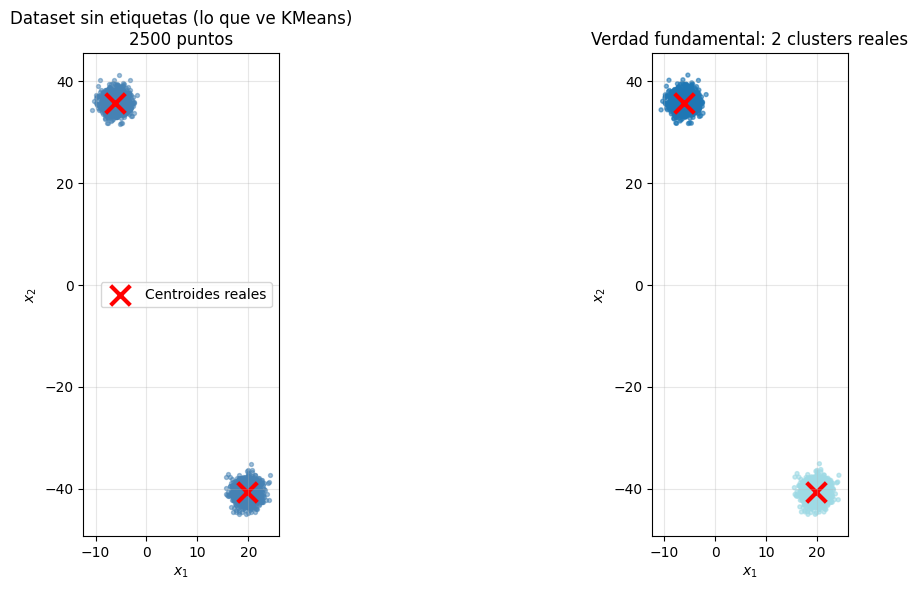

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(X[:, 0], X[:, 1], s=8, alpha=0.5, c='steelblue')
axes[0].scatter(centros_reales[:, 0], centros_reales[:, 1], s=200, c='red',
                marker='x', linewidths=3, label='Centroides reales')
axes[0].set_title(f'Dataset sin etiquetas (lo que ve KMeans)\n{X.shape[0]} puntos', fontsize=12)
axes[0].set_xlabel('$x_1$'); axes[0].set_ylabel('$x_2$')
axes[0].legend(); axes[0].set_aspect('equal'); axes[0].grid(True, alpha=0.3)

axes[1].scatter(X[:, 0], X[:, 1], s=8, alpha=0.6, c=y_true, cmap='tab20')
axes[1].scatter(centros_reales[:, 0], centros_reales[:, 1], s=200, c='red',
                marker='x', linewidths=3)
axes[1].set_title(f'Verdad fundamental: {n_real} clusters reales', fontsize=12)
axes[1].set_xlabel('$x_1$'); axes[1].set_ylabel('$x_2$')
axes[1].set_aspect('equal'); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 4. Método del Codo (Inertia)

El **método del codo** consiste en entrenar KMeans para distintos valores de $k$ y graficar la inercia. La **inercia** es la suma de las distancias al cuadrado de cada punto a su centroide asignado.

Comportamiento esperado:

- Para $k=1$: la inercia es altísima (todos los puntos contra un único centroide)
- A medida que $k$ aumenta: la inercia disminuye monotónicamente
- Cuando $k$ alcanza el verdadero número de clusters: la inercia tiene una caída pronunciada
- Para $k$ mayor al verdadero: la inercia sigue bajando pero mucho más lentamente

El **codo** es ese punto de inflexión. Es nuestro candidato a $k$ óptimo. Como sabemos que el número real es `n_real`, marcamos esa posición con una línea vertical para verificar visualmente si el codo coincide.

In [6]:
K_MAX = 20
k_values = list(range(1, K_MAX + 1))

modelos_kmeans = []
inertias = []

for k in k_values:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X)
    modelos_kmeans.append(km)
    inertias.append(km.inertia_)

for k, inercia in zip(k_values, inertias):
    print(f'k = {k:>2} | Inercia = {inercia:>12.2f}')

k =  1 | Inercia =   4090014.73
k =  2 | Inercia =      9718.55
k =  3 | Inercia =      8125.25
k =  4 | Inercia =      6549.93
k =  5 | Inercia =      5433.86
k =  6 | Inercia =      4464.59
k =  7 | Inercia =      3983.88
k =  8 | Inercia =      3494.36
k =  9 | Inercia =      3227.68
k = 10 | Inercia =      2971.27
k = 11 | Inercia =      2757.90
k = 12 | Inercia =      2603.62
k = 13 | Inercia =      2315.37
k = 14 | Inercia =      2200.20
k = 15 | Inercia =      2068.56
k = 16 | Inercia =      1954.36
k = 17 | Inercia =      1851.64
k = 18 | Inercia =      1740.72
k = 19 | Inercia =      1673.45
k = 20 | Inercia =      1604.14


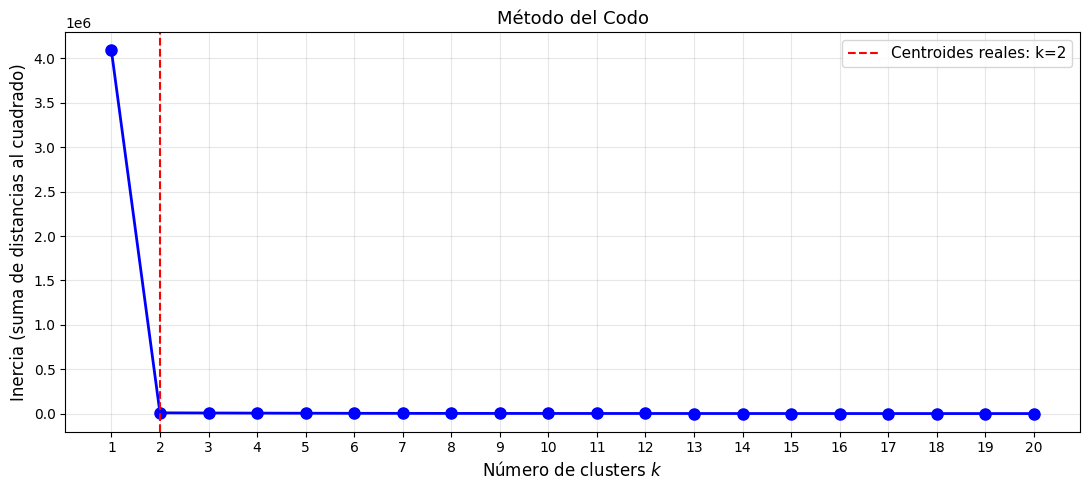

In [7]:
plt.figure(figsize=(11, 5))
plt.plot(k_values, inertias, 'bo-', linewidth=2, markersize=8)
plt.axvline(x=n_real, color='red', linestyle='--', linewidth=1.5,
            label=f'Centroides reales: k={n_real}')
plt.xlabel('Número de clusters $k$', fontsize=12)
plt.ylabel('Inercia (suma de distancias al cuadrado)', fontsize=12)
plt.title('Método del Codo', fontsize=13)
plt.xticks(k_values)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 5. Silhouette Score

El silhouette score complementa al método del codo. Mientras que la inercia siempre disminuye con más clusters, el silhouette score tiene un **máximo claro** en el $k$ óptimo, lo que lo hace más decisivo.

**Fórmula del coeficiente de silueta** para un punto $i$:

$$s_i = \frac{b_i - a_i}{\max(a_i, b_i)}$$

donde:
- $a_i$ = distancia media a todos los demás puntos del **mismo** cluster
- $b_i$ = distancia media al cluster **vecino más cercano**

**Interpretación:**

- $s_i$ cercano a $+1$: el punto está bien asignado, lejos de otros clusters
- $s_i$ cercano a $0$: el punto está en la frontera entre dos clusters
- $s_i$ negativo: el punto probablemente está mal asignado

El silhouette score global es el promedio de $s_i$ sobre todos los puntos. Empezamos en $k=2$ porque la fórmula necesita al menos dos clusters para calcular $b_i$.

In [8]:
k_values_sil = list(range(2, K_MAX + 1))
silhouette_scores = []

for k in k_values_sil:
    labels = modelos_kmeans[k - 1].labels_
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

best_k = k_values_sil[int(np.argmax(silhouette_scores))]
best_score = max(silhouette_scores)

for k, score in zip(k_values_sil, silhouette_scores):
    marca = '  ← óptimo' if k == best_k else ('  (real)' if k == n_real else '')
    print(f'k = {k:>2} | Silhouette = {score:.4f}{marca}')

print(f'\nMejor k según silhouette: {best_k} (score = {best_score:.4f})')
print(f'Centroides reales       : {n_real}')
print(f'Coincidencia            : {"SÍ" if best_k == n_real else "NO"}')

k =  2 | Silhouette = 0.9694  ← óptimo
k =  3 | Silhouette = 0.6397
k =  4 | Silhouette = 0.3131
k =  5 | Silhouette = 0.3259
k =  6 | Silhouette = 0.3301
k =  7 | Silhouette = 0.3227
k =  8 | Silhouette = 0.3167
k =  9 | Silhouette = 0.3076
k = 10 | Silhouette = 0.3086
k = 11 | Silhouette = 0.3100
k = 12 | Silhouette = 0.2992
k = 13 | Silhouette = 0.3187
k = 14 | Silhouette = 0.3110
k = 15 | Silhouette = 0.3179
k = 16 | Silhouette = 0.3179
k = 17 | Silhouette = 0.3123
k = 18 | Silhouette = 0.3211
k = 19 | Silhouette = 0.3099
k = 20 | Silhouette = 0.3204

Mejor k según silhouette: 2 (score = 0.9694)
Centroides reales       : 2
Coincidencia            : SÍ


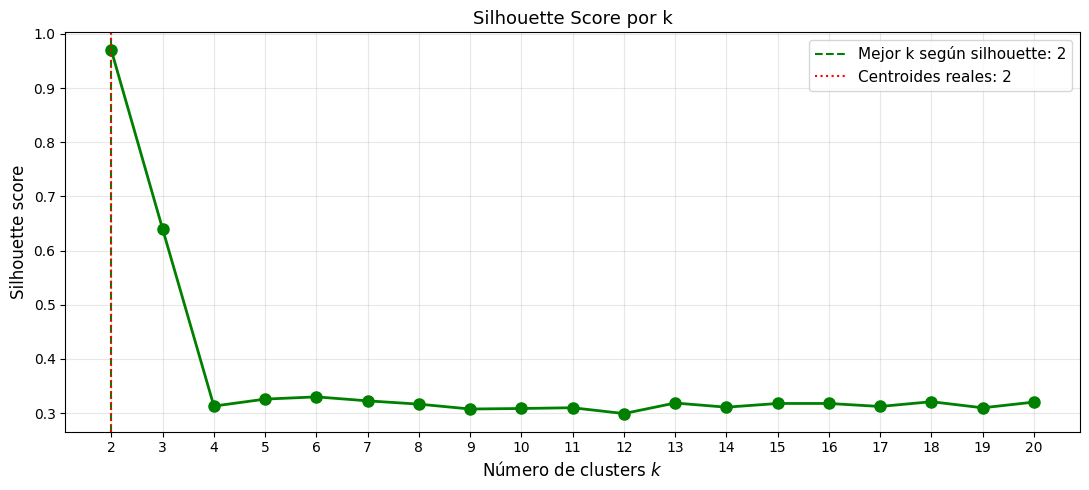

In [9]:
plt.figure(figsize=(11, 5))
plt.plot(k_values_sil, silhouette_scores, 'go-', linewidth=2, markersize=8)
plt.axvline(x=best_k, color='green', linestyle='--', linewidth=1.5,
            label=f'Mejor k según silhouette: {best_k}')
plt.axvline(x=n_real, color='red', linestyle=':', linewidth=1.5,
            label=f'Centroides reales: {n_real}')
plt.xlabel('Número de clusters $k$', fontsize=12)
plt.ylabel('Silhouette score', fontsize=12)
plt.title('Silhouette Score por k', fontsize=13)
plt.xticks(k_values_sil)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Diagramas de silueta

El score promedio puede ocultar problemas locales: tal vez un cluster es perfecto y otro malísimo, dando un promedio aceptable. El **diagrama de silueta** muestra el coeficiente de **cada** punto, agrupado por cluster, lo que permite diagnosticar el clustering visualmente.

**Cómo leer el diagrama:**

- Cada "cuchillo" horizontal representa un cluster
- El **ancho** del cuchillo = número de puntos del cluster
- El **largo** hacia la derecha = qué tan bien definido está el cluster
- La línea roja vertical = score promedio global
- Lo ideal: todos los cuchillos cruzan la línea roja y son de tamaño similar

Mostramos cuatro candidatos: el k óptimo según silhouette, el k real, y dos vecinos para comparar.

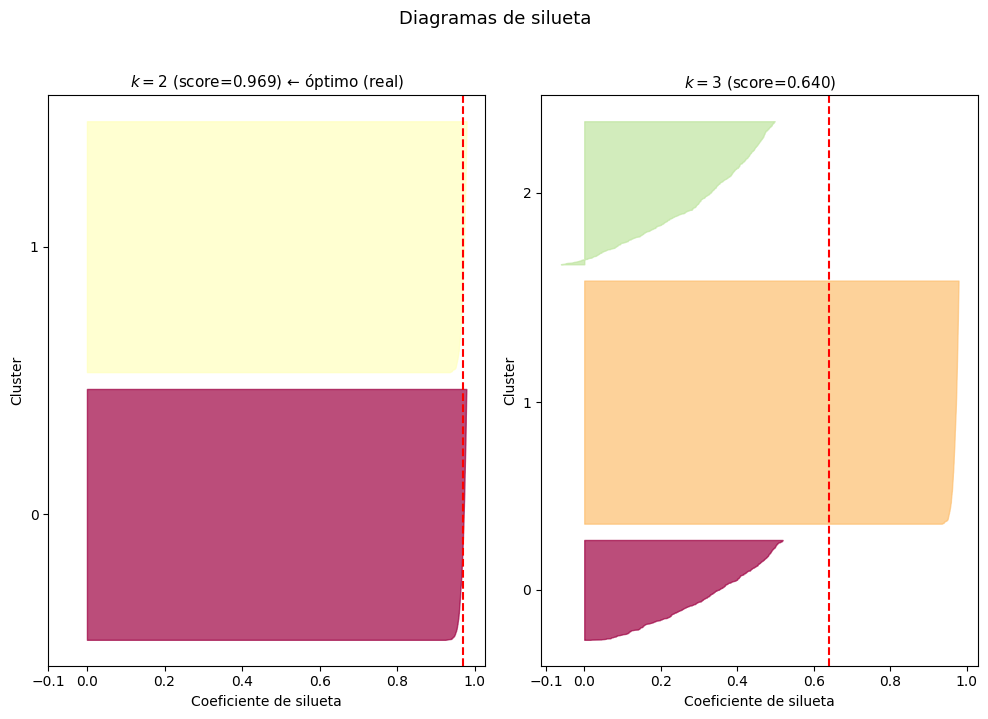

In [10]:
candidatos = sorted(set([
    max(2, best_k - 1),
    best_k,
    min(K_MAX, best_k + 1),
    n_real if n_real >= 2 else 2
]))
candidatos = [k for k in candidatos if 2 <= k <= K_MAX][:4]

n_plots = len(candidatos)
fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 7))
if n_plots == 1:
    axes = [axes]

for ax, k in zip(axes, candidatos):
    labels = modelos_kmeans[k - 1].labels_
    coefs = silhouette_samples(X, labels)
    score_medio = silhouette_scores[k - 2]

    padding = len(X) // 30
    pos = padding
    ticks = []

    for i in range(k):
        coeffs_cluster = coefs[labels == i]
        coeffs_cluster.sort()
        color = mpl.cm.Spectral(i / k)
        ax.fill_betweenx(np.arange(pos, pos + len(coeffs_cluster)), 0, coeffs_cluster,
                         facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs_cluster) // 2)
        pos += len(coeffs_cluster) + padding

    ax.yaxis.set_major_locator(FixedLocator(ticks))
    ax.yaxis.set_major_formatter(FixedFormatter(range(k)))
    ax.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
    ax.set_xlabel('Coeficiente de silueta', fontsize=10)
    ax.set_ylabel('Cluster', fontsize=10)
    ax.axvline(x=score_medio, color='red', linestyle='--', linewidth=1.5)

    extra = ''
    if k == best_k:
        extra = ' ← óptimo'
    if k == n_real:
        extra += ' (real)'
    ax.set_title(f'$k={k}$ (score={score_medio:.3f}){extra}', fontsize=11)

plt.suptitle('Diagramas de silueta', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 7. Entrenamiento final con el k óptimo

Usamos el $k$ sugerido por el silhouette score para entrenar el modelo definitivo. Reutilizamos el modelo ya entrenado durante la búsqueda, evitando re-entrenar.

In [11]:
kmeans_final = modelos_kmeans[best_k - 1]
labels_pred = kmeans_final.labels_
centros_pred = kmeans_final.cluster_centers_

print(f'Modelo final: KMeans con k={best_k}')
print(f'Inercia final: {kmeans_final.inertia_:.2f}')
print(f'Silhouette score final: {silhouette_scores[best_k - 2]:.4f}')

Modelo final: KMeans con k=2
Inercia final: 9718.55
Silhouette score final: 0.9694


## 8. Validación visual: predicción vs realidad

El test definitivo: comparar los clusters encontrados por KMeans contra los centroides reales que generaron los datos. Si los métodos del codo y silhouette funcionaron, ambos paneles deben verse esencialmente iguales (los colores pueden no coincidir porque los IDs de cluster son arbitrarios, pero las **agrupaciones** deben ser idénticas).

Las cruces rojas son los centroides reales. Las equis negras son los centroides encontrados por KMeans. Lo ideal: cada equis negra cae sobre una cruz roja.

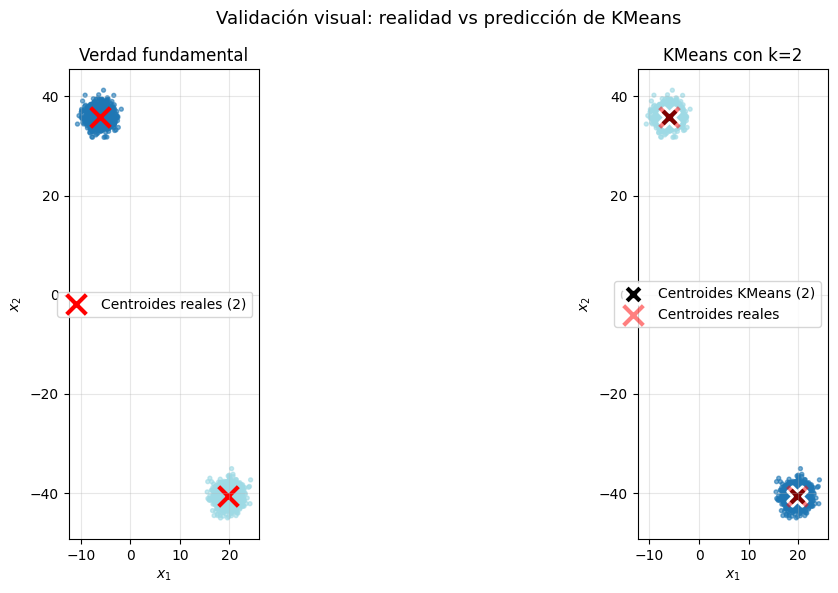

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(X[:, 0], X[:, 1], s=8, alpha=0.6, c=y_true, cmap='tab20')
axes[0].scatter(centros_reales[:, 0], centros_reales[:, 1], s=200, c='red',
                marker='x', linewidths=3, label=f'Centroides reales ({n_real})')
axes[0].set_title('Verdad fundamental', fontsize=12)
axes[0].set_xlabel('$x_1$'); axes[0].set_ylabel('$x_2$')
axes[0].legend(); axes[0].set_aspect('equal'); axes[0].grid(True, alpha=0.3)

axes[1].scatter(X[:, 0], X[:, 1], s=8, alpha=0.6, c=labels_pred, cmap='tab20')
axes[1].scatter(centros_pred[:, 0], centros_pred[:, 1], s=200, c='black',
                marker='X', linewidths=2, edgecolors='white',
                label=f'Centroides KMeans ({best_k})')
axes[1].scatter(centros_reales[:, 0], centros_reales[:, 1], s=200, c='red',
                marker='x', linewidths=3, alpha=0.5, label='Centroides reales')
axes[1].set_title(f'KMeans con k={best_k}', fontsize=12)
axes[1].set_xlabel('$x_1$'); axes[1].set_ylabel('$x_2$')
axes[1].legend(); axes[1].set_aspect('equal'); axes[1].grid(True, alpha=0.3)

plt.suptitle('Validación visual: realidad vs predicción de KMeans', fontsize=13)
plt.tight_layout()
plt.show()

## 9. Distancia entre centroides reales y encontrados

Para cuantificar la calidad del ajuste, calculamos para cada centroide real la distancia al centroide predicho más cercano. Si KMeans encontró bien la estructura, todas estas distancias deben ser pequeñas comparadas con `distancia_minima` (la separación entre clusters).

In [13]:
if best_k == n_real:
    distancias_centros = []
    for centro_real in centros_reales:
        dist_min = np.min(np.linalg.norm(centros_pred - centro_real, axis=1))
        distancias_centros.append(dist_min)
    distancias_centros = np.array(distancias_centros)

    print(f'Distancia media entre centroides reales y predichos: {distancias_centros.mean():.4f}')
    print(f'Distancia máxima                                    : {distancias_centros.max():.4f}')
    print(f'Distancia mínima                                    : {distancias_centros.min():.4f}')
    print(f'Distancia entre clusters (referencia)               : {dist_usada:.4f}')
    print(f'\nLas distancias deben ser mucho menores que {dist_usada:.2f} para considerar el ajuste exitoso.')
else:
    print(f'best_k ({best_k}) != n_real ({n_real})')
    print('La comparación uno a uno solo es válida cuando ambos coinciden.')

Distancia media entre centroides reales y predichos: 0.0641
Distancia máxima                                    : 0.0804
Distancia mínima                                    : 0.0478
Distancia entre clusters (referencia)               : 12.0000

Las distancias deben ser mucho menores que 12.00 para considerar el ajuste exitoso.


---
## 10. Experimento: efectividad para distintos valores de N

Para demostrar que el método funciona con cualquier número de centroides en el rango pedido (1 a 20), repetimos el flujo completo para cinco valores distintos de N: 3, 7, 11, 15 y 19. Para cada uno comparamos el k que sugiere el silhouette score contra el N real.

Si el método es efectivo, en todos los casos el silhouette debe identificar el N correcto.

In [14]:
def experimento_n(n_centroides, semilla):
    Xe, _, centros_e, n_real_e, _ = generar_dataset(
        n_centroides=n_centroides,
        distancia_minima=12.0,
        bounds=50.0,
        n_muestras=2000,
        cluster_std=1.4,
        random_state=semilla
    )

    k_max_local = min(20, max(n_real_e + 5, 10))
    inercias_e = []
    sil_e = []
    modelos_e = []

    for k in range(1, k_max_local + 1):
        km = KMeans(n_clusters=k, n_init=10, random_state=semilla)
        km.fit(Xe)
        modelos_e.append(km)
        inercias_e.append(km.inertia_)
        if k >= 2:
            sil_e.append(silhouette_score(Xe, km.labels_))

    if len(sil_e) > 0:
        best_k_e = int(np.argmax(sil_e)) + 2
    else:
        best_k_e = 1

    return Xe, centros_e, n_real_e, best_k_e, modelos_e[best_k_e - 1]

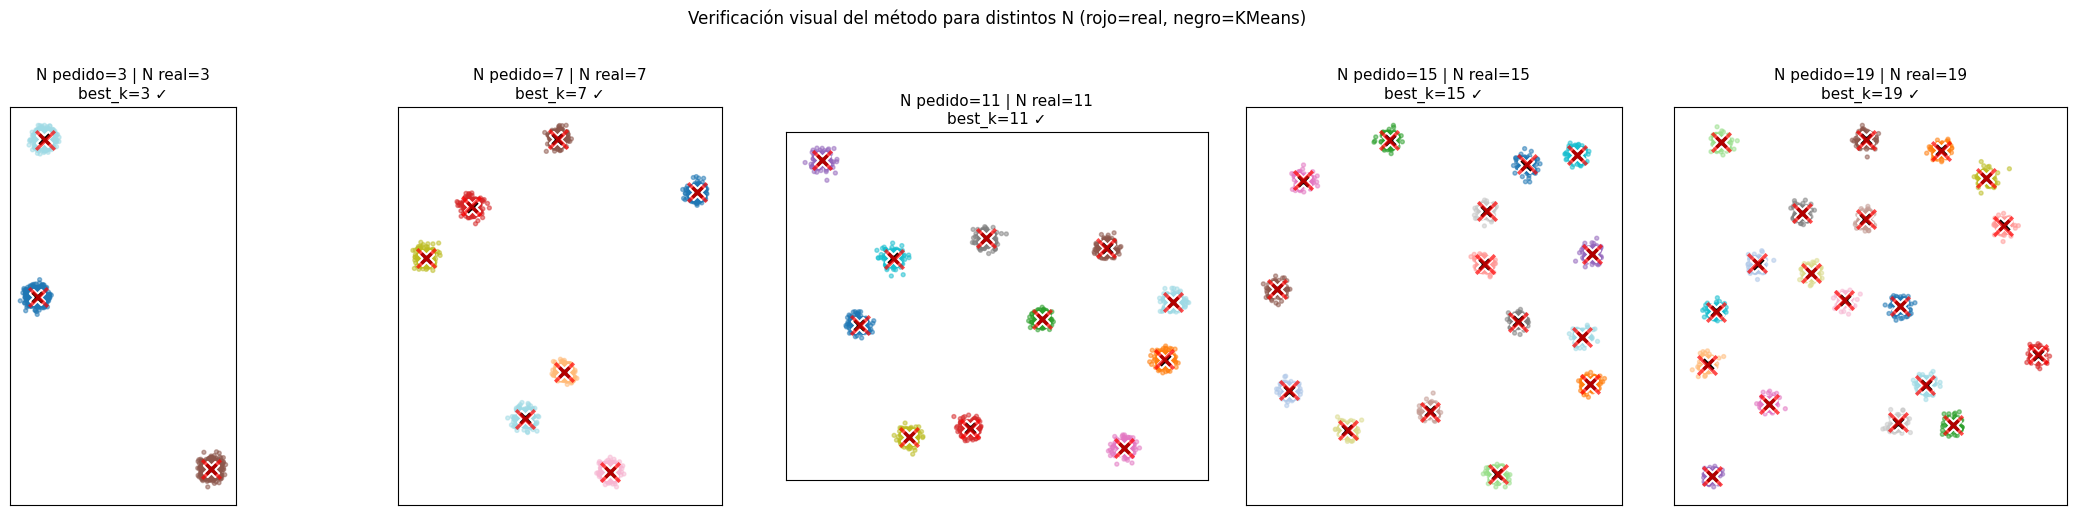

N pedido   N real     best_k     Acierto   
----------------------------------------
3          3          3          SÍ        
7          7          7          SÍ        
11         11         11         SÍ        
15         15         15         SÍ        
19         19         19         SÍ        

Aciertos totales: 5/5


In [15]:
valores_n = [3, 7, 11, 15, 19]
semillas = [11, 22, 33, 44, 55]

fig, axes = plt.subplots(1, 5, figsize=(22, 5))

resultados = []
for ax, n_pedido, semilla in zip(axes, valores_n, semillas):
    Xe, centros_e, n_real_e, best_k_e, modelo_e = experimento_n(n_pedido, semilla)

    ax.scatter(Xe[:, 0], Xe[:, 1], s=8, alpha=0.5, c=modelo_e.labels_, cmap='tab20')
    ax.scatter(modelo_e.cluster_centers_[:, 0], modelo_e.cluster_centers_[:, 1],
               s=120, c='black', marker='X', edgecolors='white', linewidths=1.5)
    ax.scatter(centros_e[:, 0], centros_e[:, 1], s=180, c='red',
               marker='x', linewidths=2.5, alpha=0.7)

    coincide = '✓' if best_k_e == n_real_e else '✗'
    ax.set_title(f'N pedido={n_pedido} | N real={n_real_e}\nbest_k={best_k_e} {coincide}',
                 fontsize=11)
    ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
    ax.set_xticks([]); ax.set_yticks([])

    resultados.append((n_pedido, n_real_e, best_k_e, best_k_e == n_real_e))

plt.suptitle('Verificación visual del método para distintos N (rojo=real, negro=KMeans)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print(f'{"N pedido":<10} {"N real":<10} {"best_k":<10} {"Acierto":<10}')
print('-' * 40)
for n_p, n_r, b_k, ok in resultados:
    print(f'{n_p:<10} {n_r:<10} {b_k:<10} {"SÍ" if ok else "NO":<10}')

aciertos = sum(1 for _, _, _, ok in resultados if ok)
print(f'\nAciertos totales: {aciertos}/{len(resultados)}')